<a href="https://colab.research.google.com/github/24215011123/Explainable-Transformer-Based-Deep-Learning-Model-for-Heart-Disease-Risk-Prediction-on-BRFSS-2015/blob/main/FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data = pd.read_sas("/content/LLCP2023XPT.zip", format="xport")
print(data.columns.tolist())


['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX2', 'LNDSXBRT', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX2', 'CELSXBRT', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINS1', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'EXRACT12', 'EXEROFT1', 'EXERHMM1', 'EXRACT22', 'EXEROFT2', 'EXERHMM2', 'STRENGTH', 'BPHIGH6', 'BPMEDS1', 'CHOLCHK3', 'TOLDHI3', 'CHOLMED3', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'FALL12MN', 'FALLINJ5', 'SMOKE100', 'SMOKDA

In [4]:
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# STEP 1: Load BRFSS 2023 raw data
# ----------------------------------------------------------
# If you have LLCP2023XPT.zip and this works, keep it.
# If it fails, unzip first and use "LLCP2023.XPT" instead.
raw_path = "/content/LLCP2023XPT.zip"  # or "/content/LLCP2023.XPT"
data = pd.read_sas(raw_path, format="xport")
print("Raw shape:", data.shape)

# ----------------------------------------------------------
# STEP 2: Select only the columns we need
# ----------------------------------------------------------
needed_cols = [
    "CVDINFR4", "CVDCRHD4", "CVDSTRK3",   # Targets for heart disease
    "_AGEG5YR",                          # Age group
    "SEXVAR",                            # Sex
    "_RFHYPE6",                          # High BP flag
    "_RFCHOL3",                          # High cholesterol flag
    "_SMOKER3",                          # Smoker status
    "DIABETE4",                          # Diabetes
    "_BMI5",                             # BMI * 100
    "_LLCPWT"                            # weight (optional, for later)
]

# Keep only existing columns (in case of version differences)
available_cols = [c for c in needed_cols if c in data.columns]
missing_cols    = [c for c in needed_cols if c not in data.columns]

print("\nAvailable columns:", available_cols)
if missing_cols:
    print("⚠️ Missing in this file (will be skipped):", missing_cols)

df = data[available_cols].copy()
print("Subset shape:", df.shape)

# ----------------------------------------------------------
# STEP 3: Create binary TARGET = HeartDisease (0/1)
# ----------------------------------------------------------
# Convert to numeric
for c in ["CVDINFR4", "CVDCRHD4", "CVDSTRK3"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Valid Yes/No responses: 1 = Yes, 2 = No
mask_valid_hd = (
    (df["CVDINFR4"].isin([1, 2])) |
    (df["CVDCRHD4"].isin([1, 2])) |
    (df["CVDSTRK3"].isin([1, 2]))
)

df = df[mask_valid_hd].copy()

df["HeartDisease"] = (
    (df["CVDINFR4"] == 1) |
    (df["CVDCRHD4"] == 1) |
    (df["CVDSTRK3"] == 1)
).astype(int)

print("\nTarget distribution (HeartDisease):")
print(df["HeartDisease"].value_counts(dropna=False))

# Drop original CVD columns if you want
df.drop(["CVDINFR4", "CVDCRHD4", "CVDSTRK3"], axis=1, inplace=True)

# ----------------------------------------------------------
# STEP 4: Build clean risk-factor features
# ----------------------------------------------------------

# 4.1 Age group (keep as category from _AGEG5YR)
df["_AGEG5YR"] = pd.to_numeric(df["_AGEG5YR"], errors="coerce")
# Remove invalid (77, 99 etc.)
df.loc[~df["_AGEG5YR"].between(1, 13), "_AGEG5YR"] = np.nan
df.rename(columns={"_AGEG5YR": "AgeGroup"}, inplace=True)

# 4.2 Sex: 1=Male, 2=Female  ->  Sex = 1 (male), 0 (female)
df["SEXVAR"] = pd.to_numeric(df["SEXVAR"], errors="coerce")
df.loc[~df["SEXVAR"].isin([1, 2]), "SEXVAR"] = np.nan
df["Sex"] = df["SEXVAR"].map({1: 1, 2: 0})
df.drop(columns=["SEXVAR"], inplace=True)

# 4.3 HighBP from _RFHYPE6: 1=Yes, 2=No
df["_RFHYPE6"] = pd.to_numeric(df["_RFHYPE6"], errors="coerce")
df.loc[~df["_RFHYPE6"].isin([1, 2]), "_RFHYPE6"] = np.nan
df["HighBP"] = df["_RFHYPE6"].map({1: 1, 2: 0})
df.drop(columns=["_RFHYPE6"], inplace=True)

# 4.4 HighChol from _RFCHOL3: 1=Yes, 2=No
df["_RFCHOL3"] = pd.to_numeric(df["_RFCHOL3"], errors="coerce")
df.loc[~df["_RFCHOL3"].isin([1, 2]), "_RFCHOL3"] = np.nan
df["HighChol"] = df["_RFCHOL3"].map({1: 1, 2: 0})
df.drop(columns=["_RFCHOL3"], inplace=True)

# 4.5 Smoker from _SMOKER3:
#  1 = Everyday, 2 = Some days → current smoker (1)
#  3 = Former, 4 = Never → non-smoker (0)
df["_SMOKER3"] = pd.to_numeric(df["_SMOKER3"], errors="coerce")
df.loc[~df["_SMOKER3"].isin([1, 2, 3, 4]), "_SMOKER3"] = np.nan
df["Smoker"] = df["_SMOKER3"].map({1: 1, 2: 1, 3: 0, 4: 0})
df.drop(columns=["_SMOKER3"], inplace=True)

# 4.6 Diabetes from DIABETE4:
# 1 = Yes → 1
# 2 = No, 3 = Gestational, 4 = Borderline → 0
df["DIABETE4"] = pd.to_numeric(df["DIABETE4"], errors="coerce")
df.loc[~df["DIABETE4"].isin([1, 2, 3, 4]), "DIABETE4"] = np.nan
df["Diabetes"] = df["DIABETE4"].map({1: 1, 2: 0, 3: 0, 4: 0})
df.drop(columns=["DIABETE4"], inplace=True)

# 4.7 BMI from _BMI5 (value / 100, ignore 9999)
df["_BMI5"] = pd.to_numeric(df["_BMI5"], errors="coerce")
df.loc[df["_BMI5"].isin([9999]), "_BMI5"] = np.nan
df["BMI"] = df["_BMI5"] / 100.0
df.drop(columns=["_BMI5"], inplace=True)

# ----------------------------------------------------------
# STEP 5: Drop rows with missing key predictors
# ----------------------------------------------------------
key_vars = ["AgeGroup", "Sex", "HighBP", "HighChol", "Smoker", "Diabetes", "BMI", "HeartDisease"]
before = len(df)
df_clean = df.dropna(subset=key_vars).copy()
after = len(df_clean)

print(f"\nDropped {before - after} rows due to missing key features.")
print("Final shape:", df_clean.shape)

# ----------------------------------------------------------
# STEP 6: Save clean, paper-style dataset
# ----------------------------------------------------------
output_path = "heart_risk_paper_style.csv"
df_clean.to_csv(output_path, index=False)

print(f"\n✅ Saved clean dataset: {output_path}")
print("Columns in final dataset:")
print(df_clean.columns.tolist())
print("\nSample:")
print(df_clean.head())


Raw shape: (433323, 350)

Available columns: ['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', '_AGEG5YR', 'SEXVAR', '_RFHYPE6', '_RFCHOL3', '_SMOKER3', 'DIABETE4', '_BMI5', '_LLCPWT']
Subset shape: (433323, 11)

Target distribution (HeartDisease):
HeartDisease
0    384557
1     48465
Name: count, dtype: int64

Dropped 100489 rows due to missing key features.
Final shape: (332533, 9)

✅ Saved clean dataset: heart_risk_paper_style.csv
Columns in final dataset:
['AgeGroup', '_LLCPWT', 'HeartDisease', 'Sex', 'HighBP', 'HighChol', 'Smoker', 'Diabetes', 'BMI']

Sample:
   AgeGroup      _LLCPWT  HeartDisease  Sex  HighBP  HighChol  Smoker  \
0      13.0   605.427887             0    0     0.0       1.0     0.0   
1      13.0  1121.992705             0    0     0.0       0.0     0.0   
2      13.0   600.963308             0    0     0.0       0.0     0.0   
3      12.0   605.427887             0    0     1.0       1.0     0.0   
4      12.0   281.711042             0    0     0.0       1.0     0.0   

   

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 11.5 MB/s eta 0:00:00
Loaded: (332533, 9)
Columns: ['AgeGroup', '_LLCPWT', 'HeartDisease', 'Sex', 'HighBP', 'HighChol', 'Smoker', 'Diabetes', 'BMI']

Target distribution (HeartDisease):
HeartDisease
0    291902
1     40631
Name: count, dtype: int64
HeartDisease
0    0.877814
1    0.122186
Name: proportion, dtype: float64

Number of samples in training set: 249399
Number of samples in testing set: 83134

Train target distribution (counts):
 HeartDisease
0    218926
1     30473
Name: count, dtype: int64
Test target distribution (counts):
 HeartDisease
0    72976
1    10158
Name: count, dtype: int64

Train target distribution (normalized):
 HeartDisease
0    0.877814
1    0.122186
Name: proportion, dtype: float64
Test target distribution (normalized):
 HeartDisease
0    0.877812
1    0.122188
Name: proportion, dtype: float64

After SMOTE balancing (TRAIN ONLY):
HeartDisease
0    218926
1    218926
Name: count, dtype: int64

🚀 Traini

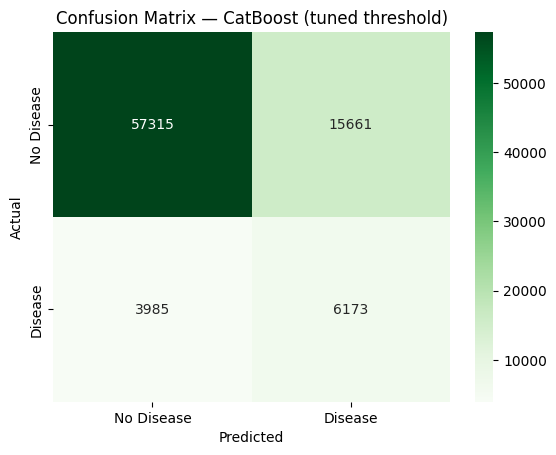

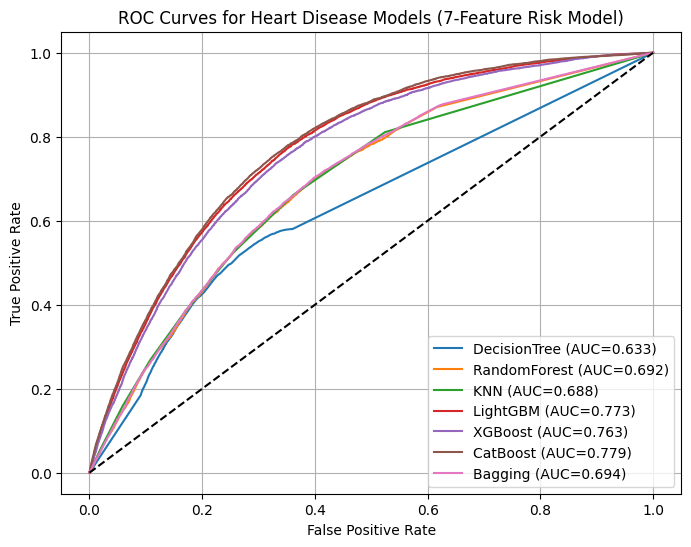


📊 Top 10 Features — CatBoost
    Feature  Importance
0  AgeGroup   20.546874
2    HighBP   18.930624
4    Smoker   18.199634
3  HighChol   15.898574
5  Diabetes   13.142721
1       Sex   11.033496
6       BMI    2.248076


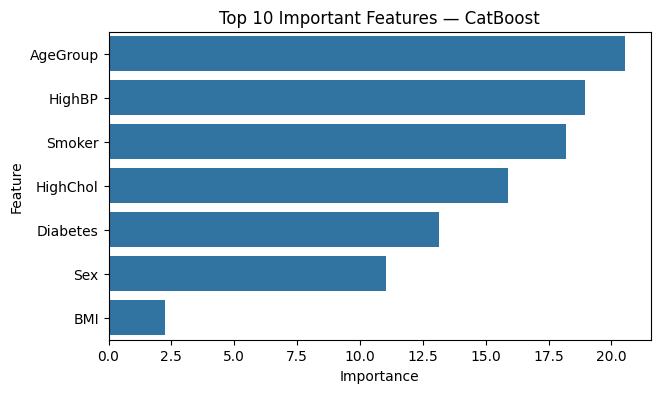


📊 Top 10 Features — LightGBM
    Feature  Importance
6       BMI        3184
0  AgeGroup        2552
1       Sex         839
3  HighChol         684
2    HighBP         639
4    Smoker         572
5  Diabetes         530


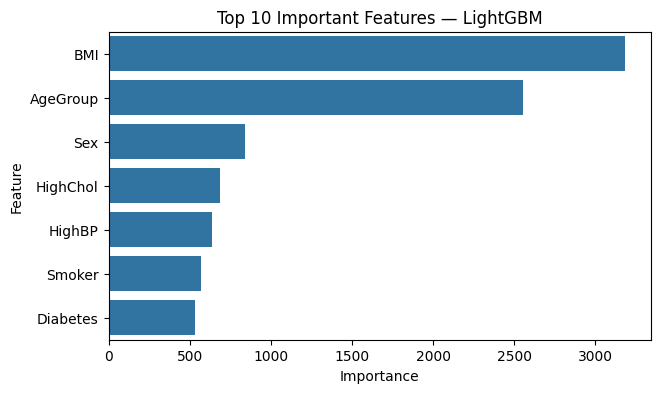


📊 Top 10 Features — XGBoost
    Feature  Importance
2    HighBP    0.306867
0  AgeGroup    0.209205
4    Smoker    0.124531
5  Diabetes    0.119744
3  HighChol    0.118558
1       Sex    0.095085
6       BMI    0.026009


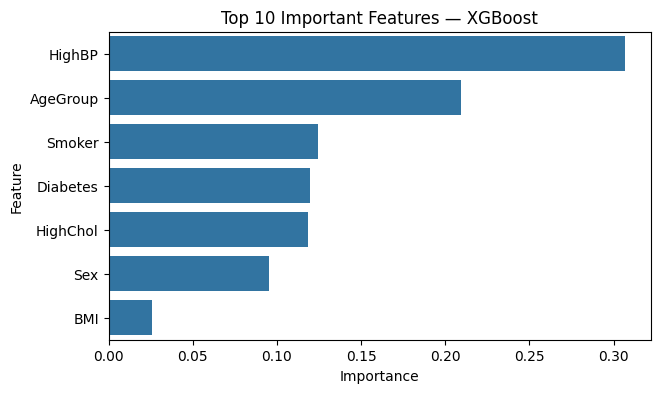


🏆 Best model by AUC (thr=0.5): CatBoost


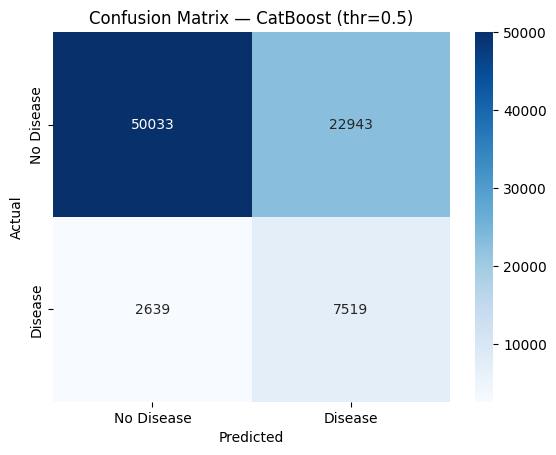

In [5]:
# ===========================================================
# FINAL – HEART DISEASE RISK PREDICTION (STRONG 7-FEATURE PIPELINE)
# ===========================================================
!pip install catboost imbalanced-learn lightgbm xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

# ===========================================================
# 1. LOAD CLEANED DATASET (7 STRONG FEATURES)
# ===========================================================
df = pd.read_csv("/content/heart_risk_paper_style.csv")
print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())

# Expected columns:
# ['AgeGroup', '_LLCPWT', 'HeartDisease', 'Sex', 'HighBP', 'HighChol',
#  'Smoker', 'Diabetes', 'BMI']

# ===========================================================
# 2. BASIC CHECKS ON TARGET
# ===========================================================
print("\nTarget distribution (HeartDisease):")
print(df["HeartDisease"].value_counts())
print(df["HeartDisease"].value_counts(normalize=True))

if len(df["HeartDisease"].unique()) < 2:
    raise SystemExit("❌ Target has only one class – cannot train model.")

# ===========================================================
# 3. FEATURE SELECTION (ONLY STRONG RISK FACTORS)
# ===========================================================
feature_cols = ["AgeGroup", "Sex", "HighBP", "HighChol",
                "Smoker", "Diabetes", "BMI"]

X = df[feature_cols].copy()
y = df["HeartDisease"].astype(int)

# ===========================================================
# 4. TRAIN–TEST SPLIT (ON ORIGINAL, IMBALANCED DATA)
# ===========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"\nNumber of samples in training set: {X_train.shape[0]}")
print(f"Number of samples in testing set: {X_test.shape[0]}")
print("\nTrain target distribution (counts):\n", y_train.value_counts())
print("Test target distribution (counts):\n", y_test.value_counts())
print("\nTrain target distribution (normalized):\n", y_train.value_counts(normalize=True))
print("Test target distribution (normalized):\n", y_test.value_counts(normalize=True))

# ===========================================================
# 5. IMPUTE MISSING (FIT ONLY ON TRAIN)
# ===========================================================
imputer = SimpleImputer(strategy="most_frequent")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=feature_cols)

# ===========================================================
# 6. BALANCE TRAIN DATA (SMOTE ONLY ON TRAIN)
# ===========================================================
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_imp, y_train)

print("\nAfter SMOTE balancing (TRAIN ONLY):")
print(y_train_res.value_counts())

# ===========================================================
# 7. SCALE (ONLY FOR KNN)
# ===========================================================
scaler = StandardScaler()
X_train_res_s = scaler.fit_transform(X_train_res)  # scaled train (for KNN)
X_test_s = scaler.transform(X_test_imp)            # scaled test (for KNN)

# ===========================================================
# 8. DEFINE MODELS
# ===========================================================
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "LightGBM": LGBMClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        n_estimators=300,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    ),
    "Bagging": BaggingClassifier(n_estimators=200, random_state=42)
}

# ===========================================================
# 9. TRAIN + EVALUATE (THRESHOLD = 0.5)
# ===========================================================
results, roc_data, probs = [], {}, {}

for name, model in models.items():
    print(f"\n🚀 Training {name} ...")

    if name == "KNN":
        # KNN – use scaled features
        model.fit(X_train_res_s, y_train_res)
        y_pred = model.predict(X_test_s)
        y_prob = model.predict_proba(X_test_s)[:, 1]
    else:
        # Other models – SMOTE-balanced train, unscaled features
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test_imp)
        y_prob = model.predict_proba(X_test_imp)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)
    probs[name] = y_prob

    results.append(dict(Model=name,
                        Accuracy=acc,
                        Precision=prec,
                        Recall=rec,
                        F1=f1,
                        AUC=auc))

# ===========================================================
# 10. RESULTS TABLE (DEFAULT THRESHOLD 0.5)
# ===========================================================
res = pd.DataFrame(results).sort_values("AUC", ascending=False)
print("\n✅ Model Evaluation Summary (sorted by AUC, thr=0.5):")
print(res.to_string(index=False))

# ===========================================================
# 11. THRESHOLD TUNING FOR BEST MODEL (MAX F1)
# ===========================================================
def tune_threshold_max_f1(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    best_thr, best_f1, best_rec, best_prec = 0.5, 0, 0, 0
    for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
        if p + r == 0:
            continue
        f1 = 2 * p * r / (p + r)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = t
            best_rec = r
            best_prec = p
    return best_thr, best_f1, best_prec, best_rec

best_model_name = res.iloc[0]["Model"]
print(f"\n🎯 Threshold tuning for best AUC model: {best_model_name}")

y_prob_best = probs[best_model_name]
best_thr, best_f1, best_prec, best_rec = tune_threshold_max_f1(y_test, y_prob_best)

print(f"🔧 Best threshold (max F1): {best_thr:.3f}")
print(f"   Precision@best_thr: {best_prec:.3f}")
print(f"   Recall@best_thr   : {best_rec:.3f}")
print(f"   F1@best_thr       : {best_f1:.3f}")

# Confusion matrix at tuned threshold
y_pred_tuned = (y_prob_best >= best_thr).astype(int)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title(f"Confusion Matrix — {best_model_name} (tuned threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===========================================================
# 12. ROC CURVES
# ===========================================================
plt.figure(figsize=(8, 6))
for n, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{n} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves for Heart Disease Models (7-Feature Risk Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# ===========================================================
# 13. FEATURE IMPORTANCE (TOP 3 MODELS)
# ===========================================================
top3 = res["Model"].head(3)
for n in top3:
    if n in ["XGBoost", "RandomForest", "CatBoost", "LightGBM"]:
        m = models[n]
        imp = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": m.feature_importances_
        }).sort_values("Importance", ascending=False).head(10)

        print(f"\n📊 Top 10 Features — {n}")
        print(imp)
        plt.figure(figsize=(7, 4))
        sns.barplot(x="Importance", y="Feature", data=imp)
        plt.title(f"Top 10 Important Features — {n}")
        plt.show()

# ===========================================================
# 14. CONFUSION MATRIX (BEST MODEL, THR=0.5) FOR REFERENCE
# ===========================================================
best = res.iloc[0]["Model"]
best_model = models[best]
print(f"\n🏆 Best model by AUC (thr=0.5): {best}")

if best == "KNN":
    y_pred_best = best_model.predict(X_test_s)
else:
    y_pred_best = best_model.predict(X_test_imp)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title(f"Confusion Matrix — {best} (thr=0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [1]:
import pandas as pd
import numpy as np

# ------------------------------------------
# STEP 0: Load RAW BRFSS 2023
# ------------------------------------------
raw_path = "/content/LLCP2023XPT.zip"   # or "/content/LLCP2023.XPT" if unzipped
data = pd.read_sas(raw_path, format="xport")
print("Raw shape:", data.shape)

# ------------------------------------------
# STEP 1: Select needed columns
# ------------------------------------------
needed_cols = [
    # Target pieces
    "CVDINFR4", "CVDCRHD4", "CVDSTRK3",

    # Age & sex
    "_AGEG5YR", "SEXVAR",

    # Core 7 risk factors
    "_RFHYPE6", "_RFCHOL3", "_SMOKER3", "DIABETE4", "_BMI5",

    # Extra extended features
    "CHCKDNY2", "CHCCOPD3", "HAVARTH4", "ADDEPEV3", "GENHLTH",
    "_TOTINDA", "_PA150R4", "_RFBMI5",

    # Optional weight
    "_LLCPWT"
]

avail = [c for c in needed_cols if c in data.columns]
miss  = [c for c in needed_cols if c not in data.columns]
print("Available:", avail)
if miss:
    print("Missing (ignored):", miss)

df = data[avail].copy()
print("Subset shape:", df.shape)

# ------------------------------------------
# STEP 2: Build HeartDisease target (same as before)
# ------------------------------------------
for c in ["CVDINFR4", "CVDCRHD4", "CVDSTRK3"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

valid_codes = [1, 2]
mask_valid_hd = (
    (df["CVDINFR4"].isin(valid_codes)) |
    (df["CVDCRHD4"].isin(valid_codes)) |
    (df["CVDSTRK3"].isin(valid_codes))
)
df = df[mask_valid_hd].copy()

df["HeartDisease"] = (
    (df["CVDINFR4"] == 1) |
    (df["CVDCRHD4"] == 1) |
    (df["CVDSTRK3"] == 1)
).astype(int)

df.drop(["CVDINFR4", "CVDCRHD4", "CVDSTRK3"], axis=1, inplace=True)

print("\nTarget distribution:")
print(df["HeartDisease"].value_counts())
print(df["HeartDisease"].value_counts(normalize=True))

# ------------------------------------------
# STEP 3: Recreate baseline 7 features (same logic as paper-style CSV)
# ------------------------------------------

# AgeGroup from _AGEG5YR
df["_AGEG5YR"] = pd.to_numeric(df["_AGEG5YR"], errors="coerce")
df.loc[~df["_AGEG5YR"].between(1, 13), "_AGEG5YR"] = np.nan
df.rename(columns={"_AGEG5YR": "AgeGroup"}, inplace=True)

# Sex: 1=Male, 2=Female -> 1/0
df["SEXVAR"] = pd.to_numeric(df["SEXVAR"], errors="coerce")
df.loc[~df["SEXVAR"].isin([1, 2]), "SEXVAR"] = np.nan
df["Sex"] = df["SEXVAR"].map({1: 1, 2: 0})
df.drop(columns=["SEXVAR"], inplace=True)

# HighBP from _RFHYPE6
df["_RFHYPE6"] = pd.to_numeric(df["_RFHYPE6"], errors="coerce")
df.loc[~df["_RFHYPE6"].isin([1, 2]), "_RFHYPE6"] = np.nan
df["HighBP"] = df["_RFHYPE6"].map({1: 1, 2: 0})
df.drop(columns=["_RFHYPE6"], inplace=True)

# HighChol from _RFCHOL3
df["_RFCHOL3"] = pd.to_numeric(df["_RFCHOL3"], errors="coerce")
df.loc[~df["_RFCHOL3"].isin([1, 2]), "_RFCHOL3"] = np.nan
df["HighChol"] = df["_RFCHOL3"].map({1: 1, 2: 0})
df.drop(columns=["_RFCHOL3"], inplace=True)

# Smoker from _SMOKER3
df["_SMOKER3"] = pd.to_numeric(df["_SMOKER3"], errors="coerce")
df.loc[~df["_SMOKER3"].isin([1, 2, 3, 4]), "_SMOKER3"] = np.nan
df["Smoker"] = df["_SMOKER3"].map({1: 1, 2: 1, 3: 0, 4: 0})
df.drop(columns=["_SMOKER3"], inplace=True)

# Diabetes from DIABETE4
df["DIABETE4"] = pd.to_numeric(df["DIABETE4"], errors="coerce")
df.loc[~df["DIABETE4"].isin([1, 2, 3, 4]), "DIABETE4"] = np.nan
df["Diabetes"] = df["DIABETE4"].map({1: 1, 2: 0, 3: 0, 4: 0})
df.drop(columns=["DIABETE4"], inplace=True)

# BMI from _BMI5
df["_BMI5"] = pd.to_numeric(df["_BMI5"], errors="coerce")
df.loc[df["_BMI5"].isin([9999]), "_BMI5"] = np.nan
df["BMI"] = df["_BMI5"] / 100.0
df.drop(columns=["_BMI5"], inplace=True)

# ------------------------------------------
# STEP 4: Extended features – convert obvious invalids to NaN
# ------------------------------------------
for col in ["CHCKDNY2", "CHCCOPD3", "HAVARTH4", "ADDEPEV3", "GENHLTH",
            "_TOTINDA", "_PA150R4", "_RFBMI5"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        # 7, 9 = don't know/refused -> NaN
        df.loc[df[col].isin([7, 9]), col] = np.nan

# ------------------------------------------
# STEP 5: Keep only rows with valid baseline 7 features
# ------------------------------------------
key_baseline = ["AgeGroup", "Sex", "HighBP", "HighChol", "Smoker", "Diabetes", "BMI", "HeartDisease"]
before = len(df)
df_clean = df.dropna(subset=key_baseline).copy()
after = len(df_clean)
print(f"\nDropped {before - after} rows due to missing key baseline features.")
print("Final shape (extended):", df_clean.shape)

# ------------------------------------------
# STEP 6: Save extended dataset
# ------------------------------------------
output_path = "heart_risk_extended.csv"
df_clean.to_csv(output_path, index=False)

print(f"\n✅ Saved extended dataset: {output_path}")
print("Columns in final dataset:")
print(df_clean.columns.tolist())


Raw shape: (433323, 350)
Available: ['CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', '_AGEG5YR', 'SEXVAR', '_RFHYPE6', '_RFCHOL3', '_SMOKER3', 'DIABETE4', '_BMI5', 'CHCKDNY2', 'CHCCOPD3', 'HAVARTH4', 'ADDEPEV3', 'GENHLTH', '_TOTINDA', '_PA150R4', '_RFBMI5', '_LLCPWT']
Subset shape: (433323, 19)

Target distribution:
HeartDisease
0    384557
1     48465
Name: count, dtype: int64
HeartDisease
0    0.888077
1    0.111923
Name: proportion, dtype: float64

Dropped 100489 rows due to missing key baseline features.
Final shape (extended): (332533, 17)

✅ Saved extended dataset: heart_risk_extended.csv
Columns in final dataset:
['AgeGroup', 'CHCKDNY2', 'CHCCOPD3', 'HAVARTH4', 'ADDEPEV3', 'GENHLTH', '_TOTINDA', '_PA150R4', '_RFBMI5', '_LLCPWT', 'HeartDisease', 'Sex', 'HighBP', 'HighChol', 'Smoker', 'Diabetes', 'BMI']


Loaded: (332533, 17)
Columns: ['AgeGroup', 'CHCKDNY2', 'CHCCOPD3', 'HAVARTH4', 'ADDEPEV3', 'GENHLTH', '_TOTINDA', '_PA150R4', '_RFBMI5', '_LLCPWT', 'HeartDisease', 'Sex', 'HighBP', 'HighChol', 'Smoker', 'Diabetes', 'BMI']

Target distribution (HeartDisease):
HeartDisease
0    291902
1     40631
Name: count, dtype: int64
HeartDisease
0    0.877814
1    0.122186
Name: proportion, dtype: float64

Using features: ['AgeGroup', 'Sex', 'HighBP', 'HighChol', 'Smoker', 'Diabetes', 'BMI', 'CHCKDNY2', 'CHCCOPD3', 'HAVARTH4', 'ADDEPEV3', 'GENHLTH', '_TOTINDA', '_PA150R4', '_RFBMI5']

Number of samples in training set: 249399
Number of samples in testing set: 83134

Train target distribution (counts):
 HeartDisease
0    218926
1     30473
Name: count, dtype: int64
Test target distribution (counts):
 HeartDisease
0    72976
1    10158
Name: count, dtype: int64

Train target distribution (normalized):
 HeartDisease
0    0.877814
1    0.122186
Name: proportion, dtype: float64
Test target distribution 

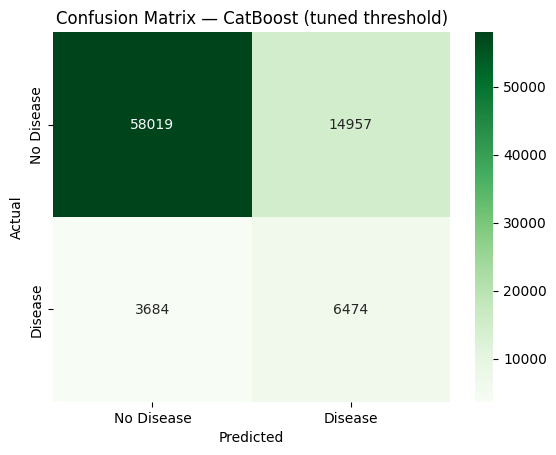

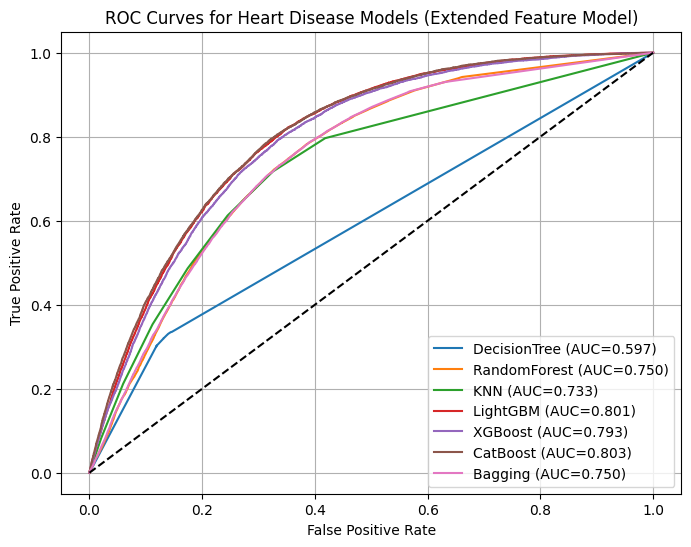


📊 Top 10 Features — CatBoost
     Feature  Importance
11   GENHLTH   14.940006
0   AgeGroup   12.187898
1        Sex    9.798880
3   HighChol    9.171921
2     HighBP    8.557095
10  ADDEPEV3    8.552770
9   HAVARTH4    8.419462
5   Diabetes    7.339245
8   CHCCOPD3    6.473363
4     Smoker    6.319478


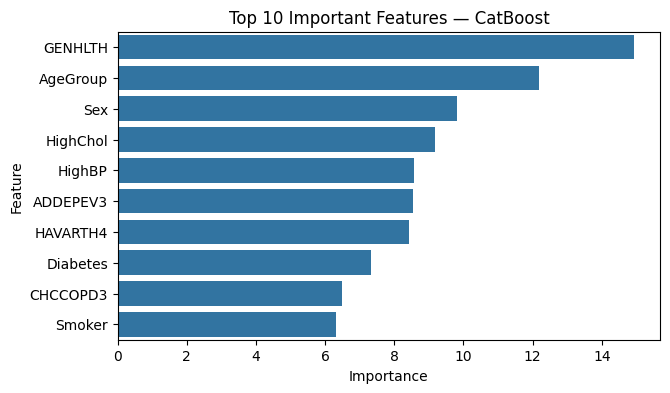


📊 Top 10 Features — LightGBM
     Feature  Importance
6        BMI        2453
0   AgeGroup        1825
11   GENHLTH        1014
1        Sex         509
3   HighChol         374
2     HighBP         364
8   CHCCOPD3         349
10  ADDEPEV3         349
4     Smoker         341
9   HAVARTH4         334


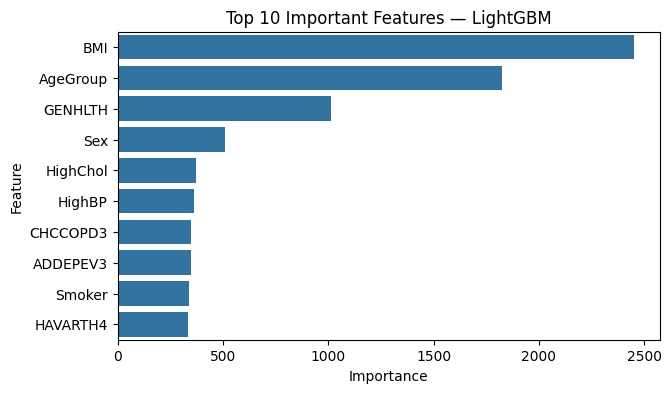


📊 Top 10 Features — XGBoost
     Feature  Importance
2     HighBP    0.240865
11   GENHLTH    0.086319
9   HAVARTH4    0.083599
3   HighChol    0.083357
1        Sex    0.076186
5   Diabetes    0.071973
0   AgeGroup    0.068779
10  ADDEPEV3    0.058089
4     Smoker    0.057521
8   CHCCOPD3    0.053816


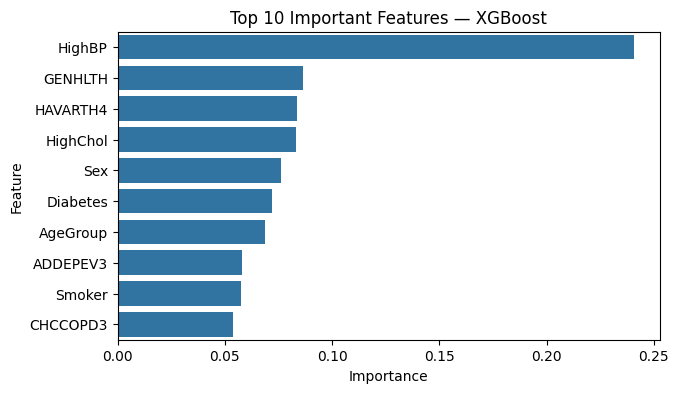


🏆 Best model by AUC (thr=0.5): CatBoost


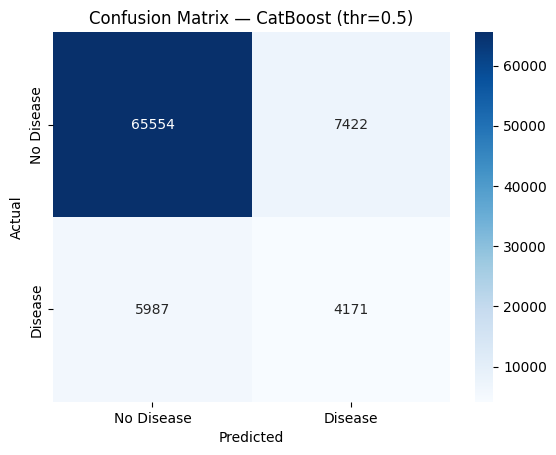

In [2]:
# ===========================================================
# FINAL – HEART DISEASE RISK PREDICTION (EXTENDED FEATURE PIPELINE)
#  - Uses baseline 7 + extra clinical/lifestyle features
#  - Dataset: heart_risk_extended.csv  (jo humne RAW BRFSS se banaya)
# ===========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

# ===========================================================
# 1. LOAD CLEANED EXTENDED DATASET
# ===========================================================
df = pd.read_csv("/content/heart_risk_extended.csv")
print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())

# Expected columns (example):
# ['AgeGroup', 'Sex', 'HighBP', 'HighChol', 'Smoker', 'Diabetes', 'BMI',
#  'CHCKDNY2', 'CHCCOPD3', 'HAVARTH4', 'ADDEPEV3', 'GENHLTH',
#  '_TOTINDA', '_PA150R4', '_RFBMI5',
#  'HeartDisease', '_LLCPWT', ...]  # extra columns ok, we won't use all

# ===========================================================
# 2. BASIC CHECKS ON TARGET
# ===========================================================
print("\nTarget distribution (HeartDisease):")
print(df["HeartDisease"].value_counts())
print(df["HeartDisease"].value_counts(normalize=True))

if len(df["HeartDisease"].unique()) < 2:
    raise SystemExit("❌ Target has only one class – cannot train model.")

# ===========================================================
# 3. FEATURE SELECTION (BASELINE 7 + EXTENDED FEATURES)
# ===========================================================
feature_cols = [
    # Baseline 7
    "AgeGroup", "Sex", "HighBP", "HighChol",
    "Smoker", "Diabetes", "BMI",

    # Extra extended clinical + lifestyle
    "CHCKDNY2",   # kidney disease
    "CHCCOPD3",   # COPD
    "HAVARTH4",   # arthritis
    "ADDEPEV3",   # depression
    "GENHLTH",    # general health
    "_TOTINDA",   # any physical activity
    "_PA150R4",   # meets 150-min rec
    "_RFBMI5"     # obesity flag
]

# Keep only columns that exist (safety)
feature_cols = [c for c in feature_cols if c in df.columns]
print("\nUsing features:", feature_cols)

X = df[feature_cols].copy()
y = df["HeartDisease"].astype(int)

# ===========================================================
# 4. TRAIN–TEST SPLIT (ON ORIGINAL, IMBALANCED DATA)
# ===========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"\nNumber of samples in training set: {X_train.shape[0]}")
print(f"Number of samples in testing set: {X_test.shape[0]}")
print("\nTrain target distribution (counts):\n", y_train.value_counts())
print("Test target distribution (counts):\n", y_test.value_counts())
print("\nTrain target distribution (normalized):\n", y_train.value_counts(normalize=True))
print("Test target distribution (normalized):\n", y_test.value_counts(normalize=True))

# ===========================================================
# 5. IMPUTE MISSING (FIT ONLY ON TRAIN)
# ===========================================================
imputer = SimpleImputer(strategy="most_frequent")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=feature_cols)

# ===========================================================
# 6. BALANCE TRAIN DATA (SMOTE ONLY ON TRAIN)
# ===========================================================
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_imp, y_train)

print("\nAfter SMOTE balancing (TRAIN ONLY):")
print(y_train_res.value_counts())

# ===========================================================
# 7. SCALE (ONLY FOR KNN)
# ===========================================================
scaler = StandardScaler()
X_train_res_s = scaler.fit_transform(X_train_res)  # scaled train (for KNN)
X_test_s = scaler.transform(X_test_imp)            # scaled test (for KNN)

# ===========================================================
# 8. DEFINE MODELS
# ===========================================================
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "LightGBM": LGBMClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        n_estimators=300,
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    ),
    "Bagging": BaggingClassifier(n_estimators=200, random_state=42)
}

# ===========================================================
# 9. TRAIN + EVALUATE (THRESHOLD = 0.5)
# ===========================================================
results, roc_data, probs = [], {}, {}

for name, model in models.items():
    print(f"\n🚀 Training {name} ...")

    if name == "KNN":
        # KNN – use scaled features
        model.fit(X_train_res_s, y_train_res)
        y_pred = model.predict(X_test_s)
        y_prob = model.predict_proba(X_test_s)[:, 1]
    else:
        # Other models – SMOTE-balanced train, unscaled features
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test_imp)
        y_prob = model.predict_proba(X_test_imp)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, auc)
    probs[name] = y_prob

    results.append(dict(Model=name,
                        Accuracy=acc,
                        Precision=prec,
                        Recall=rec,
                        F1=f1,
                        AUC=auc))

# ===========================================================
# 10. RESULTS TABLE (DEFAULT THRESHOLD 0.5)
# ===========================================================
res = pd.DataFrame(results).sort_values("AUC", ascending=False)
print("\n✅ Model Evaluation Summary (sorted by AUC, thr=0.5):")
print(res.to_string(index=False))

# ===========================================================
# 11. THRESHOLD TUNING FOR BEST MODEL (MAX F1)
# ===========================================================
def tune_threshold_max_f1(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    best_thr, best_f1, best_rec, best_prec = 0.5, 0, 0, 0
    for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
        if p + r == 0:
            continue
        f1 = 2 * p * r / (p + r)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = t
            best_rec = r
            best_prec = p
    return best_thr, best_f1, best_prec, best_rec

best_model_name = res.iloc[0]["Model"]
print(f"\n🎯 Threshold tuning for best AUC model: {best_model_name}")

y_prob_best = probs[best_model_name]
best_thr, best_f1, best_prec, best_rec = tune_threshold_max_f1(y_test, y_prob_best)

print(f"🔧 Best threshold (max F1): {best_thr:.3f}")
print(f"   Precision@best_thr: {best_prec:.3f}")
print(f"   Recall@best_thr   : {best_rec:.3f}")
print(f"   F1@best_thr       : {best_f1:.3f}")

# Confusion matrix at tuned threshold
y_pred_tuned = (y_prob_best >= best_thr).astype(int)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title(f"Confusion Matrix — {best_model_name} (tuned threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===========================================================
# 12. ROC CURVES
# ===========================================================
plt.figure(figsize=(8, 6))
for n, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{n} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves for Heart Disease Models (Extended Feature Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# ===========================================================
# 13. FEATURE IMPORTANCE (TOP 3 MODELS)
# ===========================================================
top3 = res["Model"].head(3)
for n in top3:
    if n in ["XGBoost", "RandomForest", "CatBoost", "LightGBM"]:
        m = models[n]
        imp = pd.DataFrame({
            "Feature": feature_cols,
            "Importance": m.feature_importances_
        }).sort_values("Importance", ascending=False).head(10)

        print(f"\n📊 Top 10 Features — {n}")
        print(imp)
        plt.figure(figsize=(7, 4))
        sns.barplot(x="Importance", y="Feature", data=imp)
        plt.title(f"Top 10 Important Features — {n}")
        plt.show()

# ===========================================================
# 14. CONFUSION MATRIX (BEST MODEL, THR=0.5) FOR REFERENCE
# ===========================================================
best = res.iloc[0]["Model"]
best_model = models[best]
print(f"\n🏆 Best model by AUC (thr=0.5): {best}")

if best == "KNN":
    y_pred_best = best_model.predict(X_test_s)
else:
    y_pred_best = best_model.predict(X_test_imp)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title(f"Confusion Matrix — {best} (thr=0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [3]:
!pip install catboost imbalanced-learn shap reportlab -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.5 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier

from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image as RLImage
from reportlab.lib.styles import getSampleStyleSheet

# ----------------------------------------------------
# Helper: training + evaluation for a given dataset
# ----------------------------------------------------
def run_catboost_pipeline(df, feature_cols, label_col="HeartDisease", model_name="Extended"):
    X = df[feature_cols].copy()
    y = df[label_col].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    imputer = SimpleImputer(strategy="most_frequent")
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train_imp, y_train)

    model = CatBoostClassifier(
        iterations=400,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )
    model.fit(X_train_res, y_train_res)

    y_prob = model.predict_proba(X_test_imp)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # threshold tuning
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    best_thr, best_f1, best_prec, best_rec = 0.5, 0, 0, 0
    for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
        if p + r == 0:
            continue
        f1_temp = 2 * p * r / (p + r)
        if f1_temp > best_f1:
            best_f1 = f1_temp
            best_thr = t
            best_prec = p
            best_rec = r

    metrics = {
        "ModelType": model_name,
        "Features": len(feature_cols),
        "AUC": auc,
        "Acc@0.5": acc,
        "Prec@0.5": prec,
        "Rec@0.5": rec,
        "F1@0.5": f1,
        "BestThr": best_thr,
        "Prec@Best": best_prec,
        "Rec@Best": best_rec,
        "F1@Best": best_f1
    }

    return model, imputer, (X_test_imp, y_test, y_prob), metrics

# ----------------------------------------------------
# Load datasets (these you already created)
# ----------------------------------------------------
baseline_df = pd.read_csv("/content/heart_risk_paper_style.csv")
extended_df = pd.read_csv("/content/heart_risk_extended.csv")

# Baseline 7 features
baseline_features = ["AgeGroup", "Sex", "HighBP", "HighChol", "Smoker", "Diabetes", "BMI"]

# Extended = baseline + extra
extended_features = baseline_features + [
    "CHCKDNY2", "CHCCOPD3", "HAVARTH4", "ADDEPEV3",
    "GENHLTH", "_TOTINDA", "_PA150R4", "_RFBMI5"
]
extended_features = [c for c in extended_features if c in extended_df.columns]

# ----------------------------------------------------
# Run pipelines
# ----------------------------------------------------
baseline_model, baseline_imputer, (Xb_test, yb_test, yb_prob), baseline_metrics = run_catboost_pipeline(
    baseline_df, baseline_features, model_name="Baseline-7"
)

extended_model, extended_imputer, (Xe_test, ye_test, ye_prob), extended_metrics = run_catboost_pipeline(
    extended_df, extended_features, model_name="Extended-15"
)

comparison_df = pd.DataFrame([baseline_metrics, extended_metrics])
comparison_path = "/content/model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("\nModel comparison:")
print(comparison_df)

# ----------------------------------------------------
# ROC and PR curves for extended model
# ----------------------------------------------------
fpr, tpr, _ = roc_curve(ye_test, ye_prob)
prec, rec, _ = precision_recall_curve(ye_test, ye_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"Extended CatBoost (AUC={extended_metrics['AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Extended Model")
plt.legend()
roc_path = "/content/roc_extended.png"
plt.savefig(roc_path, bbox_inches="tight")
plt.close()

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Extended Model")
pr_path = "/content/pr_extended.png"
plt.savefig(pr_path, bbox_inches="tight")
plt.close()

# ----------------------------------------------------
# SHAP analysis for extended model
# ----------------------------------------------------
sample_size = min(5000, Xe_test.shape[0])
Xe_sample = Xe_test[:sample_size]

explainer = shap.TreeExplainer(extended_model)
shap_values = explainer.shap_values(Xe_sample)

plt.figure()
shap.summary_plot(shap_values, Xe_sample, feature_names=extended_features, show=False)
shap_beeswarm_path = "/content/shap_beeswarm_extended.png"
plt.savefig(shap_beeswarm_path, bbox_inches="tight")
plt.close()

plt.figure()
shap.summary_plot(shap_values, Xe_sample, feature_names=extended_features, plot_type="bar", show=False)
shap_bar_path = "/content/shap_bar_extended.png"
plt.savefig(shap_bar_path, bbox_inches="tight")
plt.close()

print("\nSaved plots:")
print(roc_path, pr_path, shap_beeswarm_path, shap_bar_path)



Model comparison:
     ModelType  Features       AUC   Acc@0.5  Prec@0.5   Rec@0.5    F1@0.5  \
0   Baseline-7         7  0.777619  0.694541  0.247481  0.734987  0.370282   
1  Extended-15        15  0.802100  0.840114  0.359764  0.395747  0.376899   

    BestThr  Prec@Best  Rec@Best   F1@Best  
0  0.603960   0.282727  0.607009  0.385773  
1  0.345318   0.303055  0.625025  0.408191  

Saved plots:
/content/roc_extended.png /content/pr_extended.png /content/shap_beeswarm_extended.png /content/shap_bar_extended.png
